In [1]:
from pathlib import Path
import cv2
import shutil
import random
import pandas as pd


# =========================================================
# 1) PATHS
# =========================================================

# مسیر دیتاست اصلی UECFOOD256
DATASET_ROOT = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/UECFOOD256"
)

# مسیر خروجی دیتاست 30 کلاسه
OUTPUT_ROOT = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food30_yolo"
)


# =========================================================
# 2) SELECTED 30 CLASSES
# =========================================================

SELECTED_CLASSES = {
    1: "rice",
    7: "sushi",
    9: "fried rice",
    12: "toast",
    13: "croissant",
    17: "hamburger",
    18: "pizza",
    19: "sandwiches",
    23: "ramen noodle",
    27: "spaghetti",
    30: "gratin",
    36: "miso soup",
    38: "sausage",
    40: "omelet",
    46: "grilled salmon",
    55: "fried chicken",
    61: "steak",
    68: "egg sunny-side up",
    80: "roast chicken",
    86: "potato salad",
    87: "green salad",
    94: "rice ball",
    97: "hot dog",
    98: "french fries",
    114: "pancake",
    123: "mushroom risotto",
    130: "chicken nugget",
    151: "scrambled egg",
    153: "lasagna",
    224: "brownie",
}


# =========================================================
# 3) UEC CLASS ID -> YOLO CLASS ID
# =========================================================

UEC_TO_YOLO = {
    uec_id: yolo_id
    for yolo_id, uec_id in enumerate(SELECTED_CLASSES.keys())
}

YOLO_TO_NAME = {
    yolo_id: class_name
    for yolo_id, class_name in enumerate(SELECTED_CLASSES.values())
}


# =========================================================
# 4) RANDOM SEED
# =========================================================

# برای اینکه هر بار split یکسان بماند
random.seed(42)


# =========================================================
# 5) CREATE OUTPUT FOLDERS
# =========================================================

for split in ["train", "val", "test"]:

    image_dir = OUTPUT_ROOT / "images" / split
    label_dir = OUTPUT_ROOT / "labels" / split

    image_dir.mkdir(parents=True, exist_ok=True)
    label_dir.mkdir(parents=True, exist_ok=True)


# =========================================================
# 6) BBOX CONVERSION FUNCTION
# =========================================================

def convert_bbox_to_yolo(
    x1,
    y1,
    x2,
    y2,
    image_width,
    image_height
):

    x_center = ((x1 + x2) / 2) / image_width
    y_center = ((y1 + y2) / 2) / image_height

    bbox_width = (x2 - x1) / image_width
    bbox_height = (y2 - y1) / image_height

    return (
        x_center,
        y_center,
        bbox_width,
        bbox_height
    )


# =========================================================
# 7) SUMMARY STORAGE
# =========================================================

summary_rows = []

total_skipped_images = 0
total_invalid_boxes = 0


# =========================================================
# 8) PROCESS EACH CLASS
# =========================================================

for uec_id, class_name in SELECTED_CLASSES.items():

    print("\n" + "=" * 70)
    print(f"Processing class {uec_id}: {class_name}")
    print("=" * 70)

    class_dir = DATASET_ROOT / str(uec_id)
    bb_file = class_dir / "bb_info.txt"


    # -----------------------------------------------------
    # Check folders/files
    # -----------------------------------------------------

    if not class_dir.exists():
        print(f"ERROR: Class folder not found: {class_dir}")
        continue

    if not bb_file.exists():
        print(f"ERROR: bb_info.txt not found: {bb_file}")
        continue


    # -----------------------------------------------------
    # Read bb_info.txt
    # -----------------------------------------------------

    annotations = {}

    with open(
        bb_file,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        # skip header:
        # img x1 y1 x2 y2
        first_line = f.readline()

        for line in f:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            img_id, x1, y1, x2, y2 = parts

            try:
                x1 = int(x1)
                y1 = int(y1)
                x2 = int(x2)
                y2 = int(y2)

            except ValueError:
                continue


            if img_id not in annotations:
                annotations[img_id] = []

            annotations[img_id].append(
                (x1, y1, x2, y2)
            )


    # -----------------------------------------------------
    # Keep only images that actually exist
    # -----------------------------------------------------

    valid_image_ids = []

    for img_id in annotations.keys():

        image_path = class_dir / f"{img_id}.jpg"

        if image_path.exists():
            valid_image_ids.append(img_id)


    # -----------------------------------------------------
    # Shuffle images
    # -----------------------------------------------------

    random.shuffle(valid_image_ids)

    total_count = len(valid_image_ids)


    # -----------------------------------------------------
    # Split:
    #
    # Stage 1:
    # 80% train pool
    # 20% test
    #
    # Stage 2:
    # train pool ->
    # 80% train
    # 20% val
    #
    # Final:
    # 64% train
    # 16% val
    # 20% test
    # -----------------------------------------------------

    test_count = int(total_count * 0.20)

    test_ids = valid_image_ids[:test_count]

    train_pool_ids = valid_image_ids[test_count:]


    val_count = int(len(train_pool_ids) * 0.20)

    val_ids = train_pool_ids[:val_count]

    train_ids = train_pool_ids[val_count:]


    splits = {
        "train": train_ids,
        "val": val_ids,
        "test": test_ids
    }


    print(
        f"Total: {total_count} | "
        f"Train: {len(train_ids)} | "
        f"Val: {len(val_ids)} | "
        f"Test: {len(test_ids)}"
    )


    # -----------------------------------------------------
    # YOLO class id
    # -----------------------------------------------------

    yolo_class_id = UEC_TO_YOLO[uec_id]


    # -----------------------------------------------------
    # Process train / val / test
    # -----------------------------------------------------

    for split_name, split_ids in splits.items():

        for img_id in split_ids:

            src_img = class_dir / f"{img_id}.jpg"

            image = cv2.imread(str(src_img))


            # Image could not be opened
            if image is None:

                print(
                    f"WARNING: Could not read image: "
                    f"{src_img}"
                )

                total_skipped_images += 1

                continue


            image_height, image_width = image.shape[:2]


            # -------------------------------------------------
            # Unique output filenames
            # -------------------------------------------------

            # Example:
            # 27_2593.jpg
            # 27_2593.txt

            dst_img_name = (
                f"{uec_id}_{img_id}.jpg"
            )

            dst_label_name = (
                f"{uec_id}_{img_id}.txt"
            )


            dst_img_path = (
                OUTPUT_ROOT
                / "images"
                / split_name
                / dst_img_name
            )

            dst_label_path = (
                OUTPUT_ROOT
                / "labels"
                / split_name
                / dst_label_name
            )


            # -------------------------------------------------
            # Copy image
            # -------------------------------------------------

            shutil.copy2(
                src_img,
                dst_img_path
            )


            # -------------------------------------------------
            # Create YOLO annotation
            # -------------------------------------------------

            label_lines = []


            for bbox in annotations[img_id]:

                x1, y1, x2, y2 = bbox


                # ---------------------------------------------
                # Clip bbox to image boundaries
                # ---------------------------------------------

                x1 = max(
                    0,
                    min(x1, image_width)
                )

                x2 = max(
                    0,
                    min(x2, image_width)
                )

                y1 = max(
                    0,
                    min(y1, image_height)
                )

                y2 = max(
                    0,
                    min(y2, image_height)
                )


                # ---------------------------------------------
                # Remove invalid boxes
                # ---------------------------------------------

                if x2 <= x1 or y2 <= y1:

                    total_invalid_boxes += 1

                    continue


                # ---------------------------------------------
                # Convert to YOLO format
                # ---------------------------------------------

                (
                    x_center,
                    y_center,
                    bbox_width,
                    bbox_height
                ) = convert_bbox_to_yolo(
                    x1,
                    y1,
                    x2,
                    y2,
                    image_width,
                    image_height
                )


                # ---------------------------------------------
                # Safety checks
                # ---------------------------------------------

                if not (
                    0 <= x_center <= 1
                    and
                    0 <= y_center <= 1
                    and
                    0 < bbox_width <= 1
                    and
                    0 < bbox_height <= 1
                ):

                    total_invalid_boxes += 1

                    continue


                # ---------------------------------------------
                # YOLO label line
                #
                # class x_center y_center width height
                # ---------------------------------------------

                label_line = (
                    f"{yolo_class_id} "
                    f"{x_center:.6f} "
                    f"{y_center:.6f} "
                    f"{bbox_width:.6f} "
                    f"{bbox_height:.6f}"
                )

                label_lines.append(label_line)


            # -------------------------------------------------
            # Write .txt annotation
            # -------------------------------------------------

            with open(
                dst_label_path,
                "w",
                encoding="utf-8"
            ) as f:

                f.write(
                    "\n".join(label_lines)
                )


    # -----------------------------------------------------
    # Add class summary
    # -----------------------------------------------------

    summary_rows.append(
        {
            "uec_id": uec_id,
            "yolo_id": yolo_class_id,
            "class_name": class_name,
            "total": total_count,
            "train": len(train_ids),
            "validation": len(val_ids),
            "test": len(test_ids)
        }
    )


# =========================================================
# 9) FINAL SUMMARY
# =========================================================

summary_df = pd.DataFrame(summary_rows)


print("\n\n")
print("=" * 80)
print("DATASET CONVERSION COMPLETED")
print("=" * 80)

print(
    summary_df.to_string(
        index=False
    )
)


print("\n" + "-" * 80)

print(
    "Total Train Images:",
    summary_df["train"].sum()
)

print(
    "Total Validation Images:",
    summary_df["validation"].sum()
)

print(
    "Total Test Images:",
    summary_df["test"].sum()
)

print(
    "Total Images:",
    summary_df["total"].sum()
)

print(
    "Skipped Images:",
    total_skipped_images
)

print(
    "Invalid Bounding Boxes:",
    total_invalid_boxes
)

print("-" * 80)


# =========================================================
# 10) SAVE SUMMARY AS CSV
# =========================================================

summary_csv_path = (
    OUTPUT_ROOT / "dataset_summary.csv"
)

summary_df.to_csv(
    summary_csv_path,
    index=False
)

print(
    f"\nSummary saved to:\n{summary_csv_path}"
)


# =========================================================
# 11) SAVE CLASS MAPPING
# =========================================================

mapping_file = (
    OUTPUT_ROOT / "class_mapping.txt"
)

with open(
    mapping_file,
    "w",
    encoding="utf-8"
) as f:

    for uec_id, class_name in SELECTED_CLASSES.items():

        yolo_id = UEC_TO_YOLO[uec_id]

        f.write(
            f"{yolo_id}\t"
            f"{uec_id}\t"
            f"{class_name}\n"
        )


print(
    f"\nClass mapping saved to:\n{mapping_file}"
)


Processing class 1: rice
Total: 620 | Train: 397 | Val: 99 | Test: 124

Processing class 7: sushi
Total: 153 | Train: 99 | Val: 24 | Test: 30

Processing class 9: fried rice
Total: 169 | Train: 109 | Val: 27 | Test: 33

Processing class 12: toast
Total: 218 | Train: 140 | Val: 35 | Test: 43

Processing class 13: croissant
Total: 120 | Train: 77 | Val: 19 | Test: 24

Processing class 17: hamburger
Total: 233 | Train: 150 | Val: 37 | Test: 46

Processing class 18: pizza
Total: 134 | Train: 87 | Val: 21 | Test: 26

Processing class 19: sandwiches
Total: 163 | Train: 105 | Val: 26 | Test: 32

Processing class 23: ramen noodle
Total: 353 | Train: 227 | Val: 56 | Test: 70

Processing class 27: spaghetti
Total: 151 | Train: 97 | Val: 24 | Test: 30

Processing class 30: gratin
Total: 115 | Train: 74 | Val: 18 | Test: 23

Processing class 36: miso soup
Total: 728 | Train: 467 | Val: 116 | Test: 145

Processing class 38: sausage
Total: 118 | Train: 76 | Val: 19 | Test: 23

Processing class 40: 

In [2]:
from pathlib import Path

OUTPUT_ROOT = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food30_yolo"
)

print("=" * 60)
print("DATASET VALIDATION")
print("=" * 60)

for split in ["train", "val", "test"]:

    image_dir = OUTPUT_ROOT / "images" / split
    label_dir = OUTPUT_ROOT / "labels" / split

    images = list(image_dir.glob("*.jpg"))
    labels = list(label_dir.glob("*.txt"))

    image_names = {p.stem for p in images}
    label_names = {p.stem for p in labels}

    missing_labels = image_names - label_names
    missing_images = label_names - image_names

    print(f"\n{split.upper()}")
    print("-" * 30)

    print("Images:", len(images))
    print("Labels:", len(labels))

    print(
        "Images without labels:",
        len(missing_labels)
    )

    print(
        "Labels without images:",
        len(missing_images)
    )

DATASET VALIDATION

TRAIN
------------------------------
Images: 3588
Labels: 3588
Images without labels: 0
Labels without images: 0

VAL
------------------------------
Images: 881
Labels: 881
Images without labels: 0
Labels without images: 0

TEST
------------------------------
Images: 1100
Labels: 1100
Images without labels: 0
Labels without images: 0


In [3]:
invalid_labels = []

for split in ["train", "val", "test"]:

    label_dir = OUTPUT_ROOT / "labels" / split

    for label_path in label_dir.glob("*.txt"):

        with open(label_path, "r") as f:

            for line_number, line in enumerate(f, start=1):

                parts = line.strip().split()

                if len(parts) != 5:
                    invalid_labels.append(
                        (label_path, line_number, "wrong format")
                    )
                    continue

                try:
                    class_id = int(parts[0])

                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])

                except ValueError:

                    invalid_labels.append(
                        (label_path, line_number, "invalid number")
                    )

                    continue

                if not 0 <= class_id <= 29:

                    invalid_labels.append(
                        (label_path, line_number, "invalid class")
                    )

                if not (
                    0 <= x_center <= 1
                    and
                    0 <= y_center <= 1
                    and
                    0 < width <= 1
                    and
                    0 < height <= 1
                ):

                    invalid_labels.append(
                        (label_path, line_number, "invalid bbox")
                    )


print("Invalid annotations:", len(invalid_labels))

if invalid_labels:
    print("\nFirst problems:")

    for problem in invalid_labels[:10]:
        print(problem)

Invalid annotations: 0


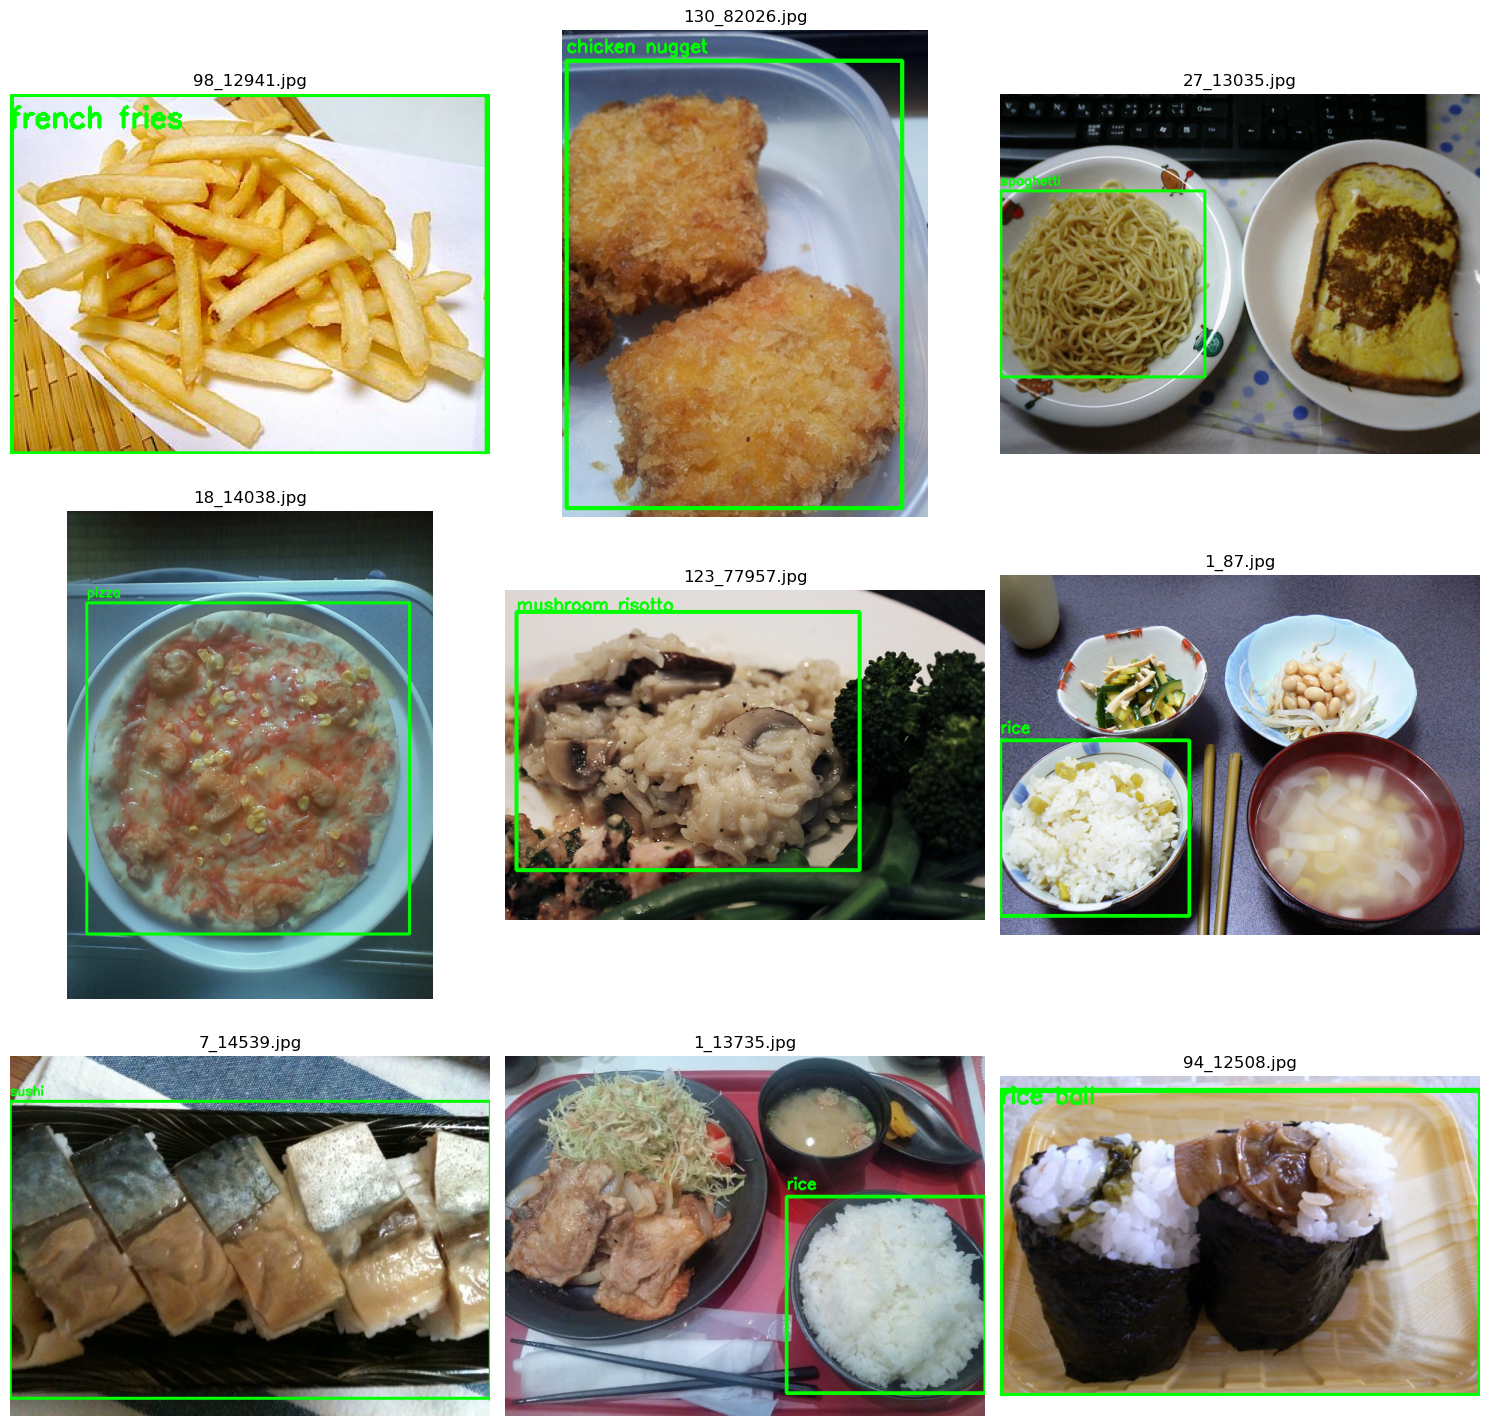

In [4]:
import cv2
import random
import matplotlib.pyplot as plt

image_dir = OUTPUT_ROOT / "images" / "train"
label_dir = OUTPUT_ROOT / "labels" / "train"

CLASS_NAMES = [
    "rice",
    "sushi",
    "fried rice",
    "toast",
    "croissant",
    "hamburger",
    "pizza",
    "sandwiches",
    "ramen noodle",
    "spaghetti",
    "gratin",
    "miso soup",
    "sausage",
    "omelet",
    "grilled salmon",
    "fried chicken",
    "steak",
    "egg sunny-side up",
    "roast chicken",
    "potato salad",
    "green salad",
    "rice ball",
    "hot dog",
    "french fries",
    "pancake",
    "mushroom risotto",
    "chicken nugget",
    "scrambled egg",
    "lasagna",
    "brownie"
]

image_paths = list(image_dir.glob("*.jpg"))

sample_images = random.sample(
    image_paths,
    min(9, len(image_paths))
)

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15, 15)
)

axes = axes.flatten()

for ax, image_path in zip(axes, sample_images):

    image = cv2.imread(str(image_path))

    height, width = image.shape[:2]

    label_path = (
        label_dir /
        f"{image_path.stem}.txt"
    )

    with open(label_path, "r") as f:

        for line in f:

            parts = line.strip().split()

            class_id = int(parts[0])

            x_center = float(parts[1])
            y_center = float(parts[2])
            box_width = float(parts[3])
            box_height = float(parts[4])

            # YOLO -> Pixel coordinates

            x1 = int(
                (x_center - box_width / 2)
                * width
            )

            y1 = int(
                (y_center - box_height / 2)
                * height
            )

            x2 = int(
                (x_center + box_width / 2)
                * width
            )

            y2 = int(
                (y_center + box_height / 2)
                * height
            )

            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                3
            )

            cv2.putText(
                image,
                CLASS_NAMES[class_id],
                (x1, max(25, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 255, 0),
                2
            )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    ax.imshow(image)
    ax.set_title(image_path.name)
    ax.axis("off")


plt.tight_layout()
plt.show()

In [5]:
from pathlib import Path

OUTPUT_ROOT = Path(
    "/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food30_yolo"
)

yaml_content = """path: /content/food30_yolo

train: images/train
val: images/val
test: images/test

names:
  0: rice
  1: sushi
  2: fried rice
  3: toast
  4: croissant
  5: hamburger
  6: pizza
  7: sandwiches
  8: ramen noodle
  9: spaghetti
  10: gratin
  11: miso soup
  12: sausage
  13: omelet
  14: grilled salmon
  15: fried chicken
  16: steak
  17: egg sunny-side up
  18: roast chicken
  19: potato salad
  20: green salad
  21: rice ball
  22: hot dog
  23: french fries
  24: pancake
  25: mushroom risotto
  26: chicken nugget
  27: scrambled egg
  28: lasagna
  29: brownie
"""

yaml_path = OUTPUT_ROOT / "dataset.yaml"

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_content)

print("Created:", yaml_path)

Created: /Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/food30_yolo/dataset.yaml


In [6]:
print(yaml_path.read_text())

path: /content/food30_yolo

train: images/train
val: images/val
test: images/test

names:
  0: rice
  1: sushi
  2: fried rice
  3: toast
  4: croissant
  5: hamburger
  6: pizza
  7: sandwiches
  8: ramen noodle
  9: spaghetti
  10: gratin
  11: miso soup
  12: sausage
  13: omelet
  14: grilled salmon
  15: fried chicken
  16: steak
  17: egg sunny-side up
  18: roast chicken
  19: potato salad
  20: green salad
  21: rice ball
  22: hot dog
  23: french fries
  24: pancake
  25: mushroom risotto
  26: chicken nugget
  27: scrambled egg
  28: lasagna
  29: brownie

